In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import learning_curve
from docx import Document

In [29]:

file_path = './BMD-2.csv'  
data = pd.read_csv(file_path)

# features and target variable
X = data[['Age', 'Weight_kg', 'Height_cm', 'BMD']]  # Feature columns
y = data['Fracture'].apply(lambda x: 1 if x == 'fracture' else 0)  # Binary encoding of target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# Train Decision Tree with depth 3
tree_depth_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth_3.fit(X_train, y_train)
y_pred_depth_3 = tree_depth_3.predict(X_test)
probs_depth_3 = tree_depth_3.predict_proba(X_test)[:, 1]

# Train Decision Tree with depth 5
tree_depth_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_depth_5.fit(X_train, y_train)
y_pred_depth_5 = tree_depth_5.predict(X_test)
probs_depth_5 = tree_depth_5.predict_proba(X_test)[:, 1]

In [31]:
# Train Random Forest with 50 estimators
rf_50 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_50.fit(X_train, y_train)
y_pred_rf_50 = rf_50.predict(X_test)
probs_rf_50 = rf_50.predict_proba(X_test)[:, 1]

# Train Random Forest with 100 estimators
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
y_pred_rf_100 = rf_100.predict(X_test)
probs_rf_100 = rf_100.predict_proba(X_test)[:, 1]

In [32]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
probs_log_reg = log_reg.predict_proba(X_test)[:, 1]

In [33]:
# Create a comparison dataframe to summarize the model results
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree (Depth 3)", "Decision Tree (Depth 5)", "Random Forest (50 Estimators)", 
              "Random Forest (100 Estimators)", "Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_depth_3), accuracy_score(y_test, y_pred_depth_5), 
                 accuracy_score(y_test, y_pred_rf_50), accuracy_score(y_test, y_pred_rf_100), 
                 accuracy_score(y_test, y_pred_log_reg)],
    "Misclassified 'no fracture'": [confusion_matrix(y_test, y_pred_depth_3)[0, 1], 
                                    confusion_matrix(y_test, y_pred_depth_5)[0, 1], 
                                    confusion_matrix(y_test, y_pred_rf_50)[0, 1], 
                                    confusion_matrix(y_test, y_pred_rf_100)[0, 1], 
                                    confusion_matrix(y_test, y_pred_log_reg)[0, 1]],
    "Misclassified 'fracture'": [confusion_matrix(y_test, y_pred_depth_3)[1, 0], 
                                 confusion_matrix(y_test, y_pred_depth_5)[1, 0], 
                                 confusion_matrix(y_test, y_pred_rf_50)[1, 0], 
                                 confusion_matrix(y_test, y_pred_rf_100)[1, 0], 
                                 confusion_matrix(y_test, y_pred_log_reg)[1, 0]]
})

print("\nModel Comparison Summary:")
print(comparison_df)


Model Comparison Summary:
                            Model  Accuracy  Misclassified 'no fracture'  \
0         Decision Tree (Depth 3)  0.784314                            4   
1         Decision Tree (Depth 5)  0.803922                            3   
2   Random Forest (50 Estimators)  0.784314                            4   
3  Random Forest (100 Estimators)  0.823529                            3   
4             Logistic Regression  0.843137                            2   

   Misclassified 'fracture'  
0                         7  
1                         7  
2                         7  
3                         6  
4                         6  


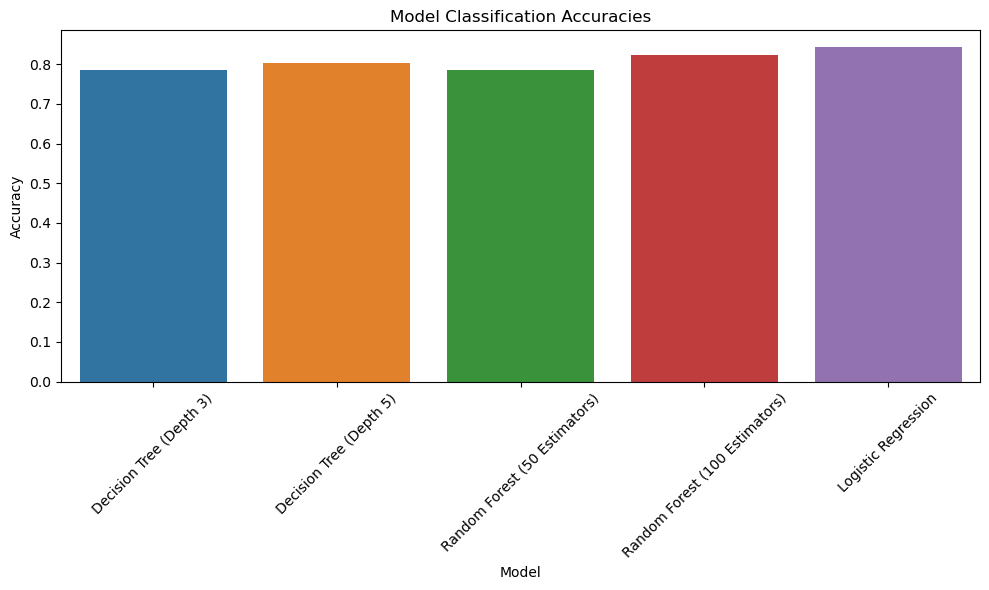

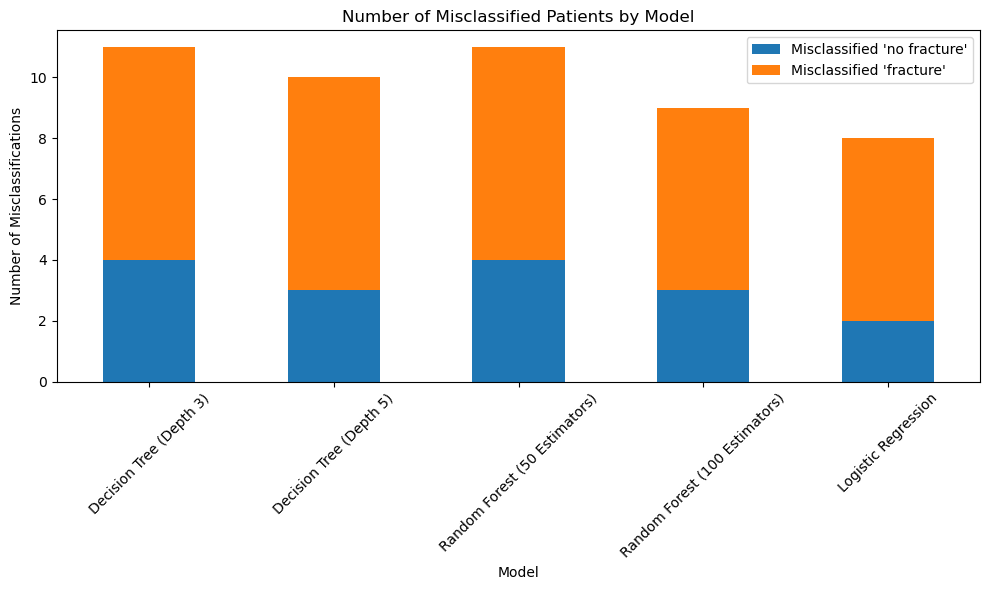

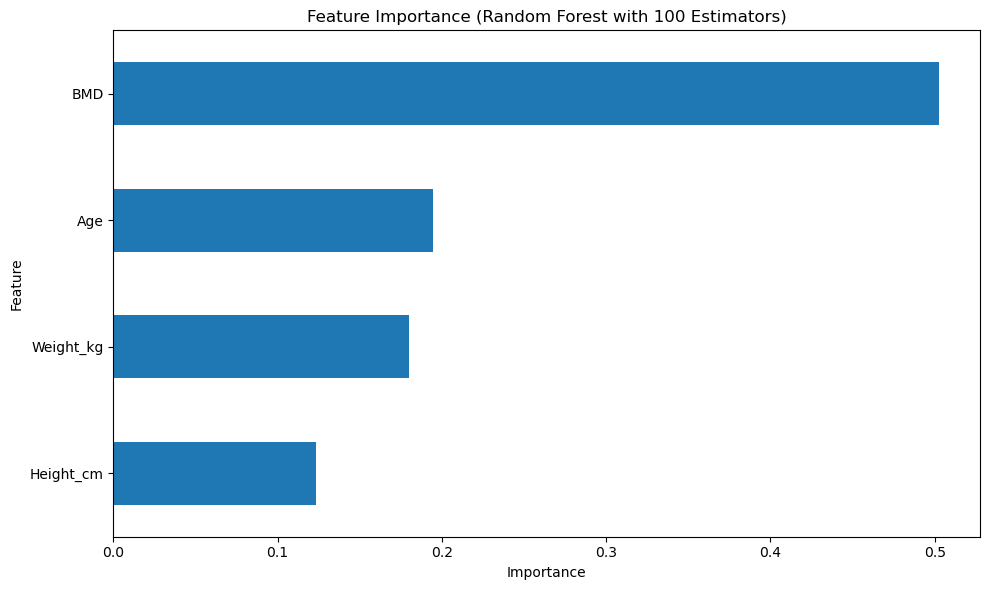

In [34]:
# Visualization 1: Bar chart for model accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=comparison_df)
plt.title("Model Classification Accuracies")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig('model_accuracies.png')
plt.show()  # Display the plot

# Visualization 2: Stacked bar chart for misclassified patients
comparison_df.set_index("Model")[["Misclassified 'no fracture'", "Misclassified 'fracture'"]].plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Number of Misclassified Patients by Model")
plt.ylabel("Number of Misclassifications")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('misclassified_patients.png')
plt.show()  # Display the plot

# Visualization 3: Feature importance from the Random Forest with 100 estimators
feature_importances = pd.Series(rf_100.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest with 100 Estimators)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()  # Display the plot


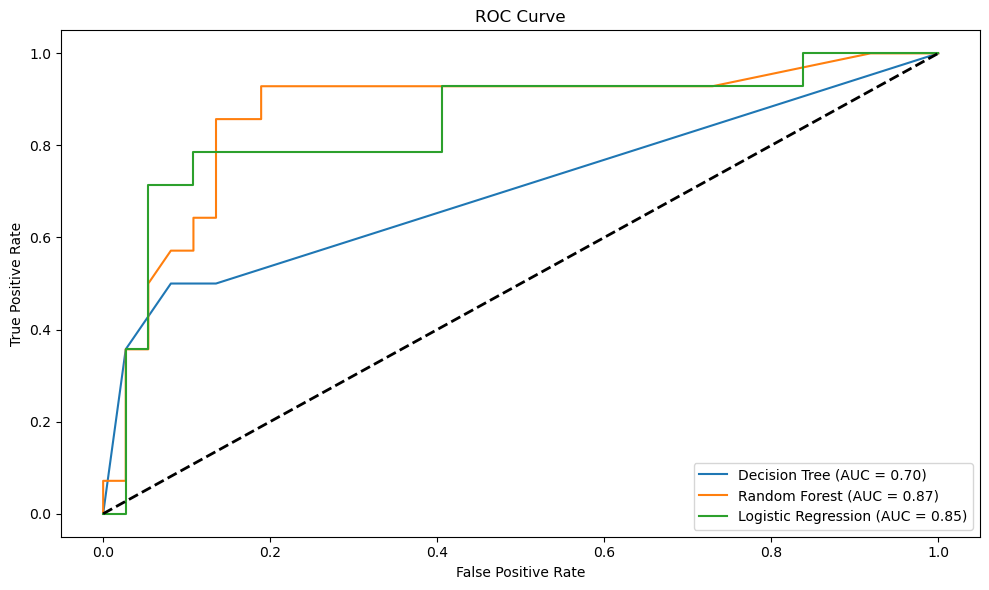

In [35]:
# Visualization 4: ROC Curve and AUC
plt.figure(figsize=(10, 6))
fpr_tree, tpr_tree, _ = roc_curve(y_test, probs_depth_5)
roc_auc_tree = auc(fpr_tree, tpr_tree)

fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf_100)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_log, tpr_log, _ = roc_curve(y_test, probs_log_reg)
roc_auc_log = auc(fpr_log, tpr_log)

plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()  # Display the plot

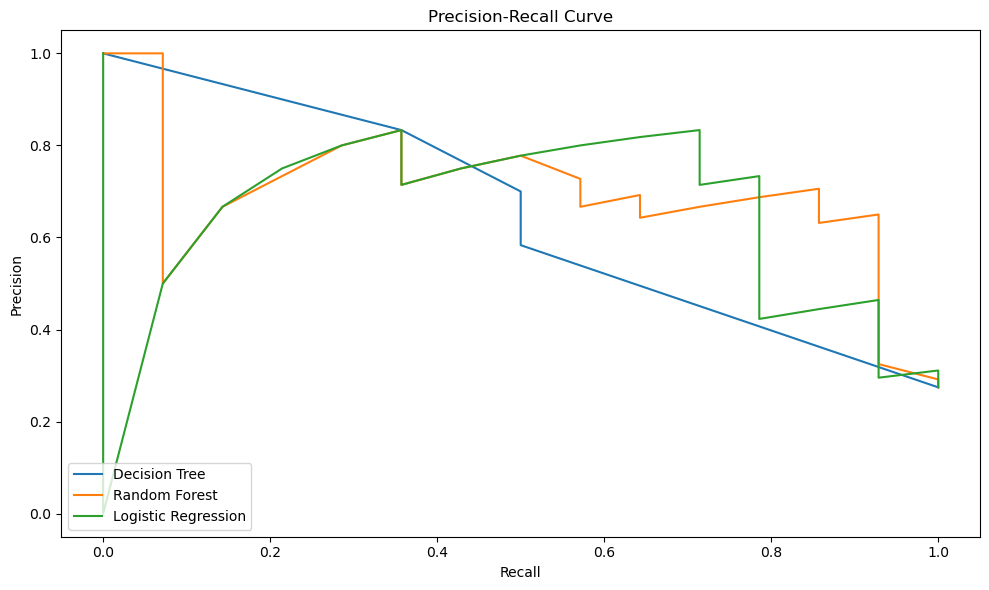

In [36]:
# Visualization 5: Precision-Recall Curve
plt.figure(figsize=(10, 6))
precision_tree, recall_tree, _ = precision_recall_curve(y_test, probs_depth_5)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, probs_rf_100)
precision_log, recall_log, _ = precision_recall_curve(y_test, probs_log_reg)

plt.plot(recall_tree, precision_tree, label='Decision Tree')
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.plot(recall_log, precision_log, label='Logistic Regression')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('precision_recall_curve.png')
plt.show()  # Display the plot

# Create decision boundary models for visualization
X_train_2d = X_train[['Age', 'BMD']]
X_test_2d = X_test[['Age', 'BMD']]
tree_depth_5_2d = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_depth_5_2d.fit(X_train_2d, y_train)

rf_100_2d = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100_2d.fit(X_train_2d, y_train)

# Plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X['Age'].min() - 1, X['Age'].max() + 1
    y_min, y_max = X['BMD'].min() - 0.1, X['BMD'].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X['Age'], X['BMD'], c=y, edgecolor='k', marker='o')
    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('BMD')

/Users/zyan/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/zyan/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


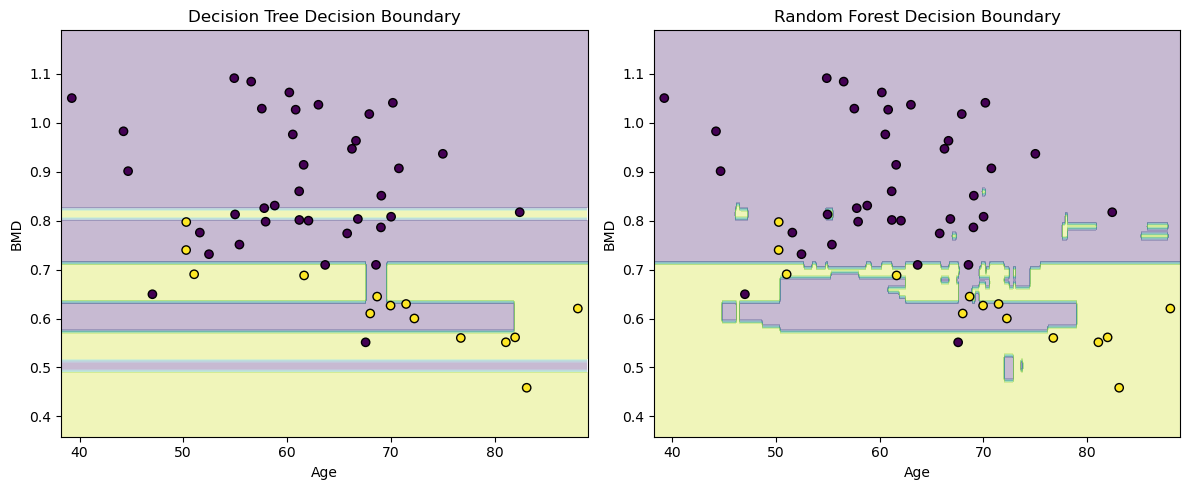

In [37]:
# Visualization 6: Plotting decision boundaries for Decision Tree and Random Forest
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(tree_depth_5_2d, X_test_2d, y_test, "Decision Tree Decision Boundary")

plt.subplot(1, 2, 2)
plot_decision_boundary(rf_100_2d, X_test_2d, y_test, "Random Forest Decision Boundary")

plt.tight_layout()
plt.savefig('decision_boundary.png')
plt.show()


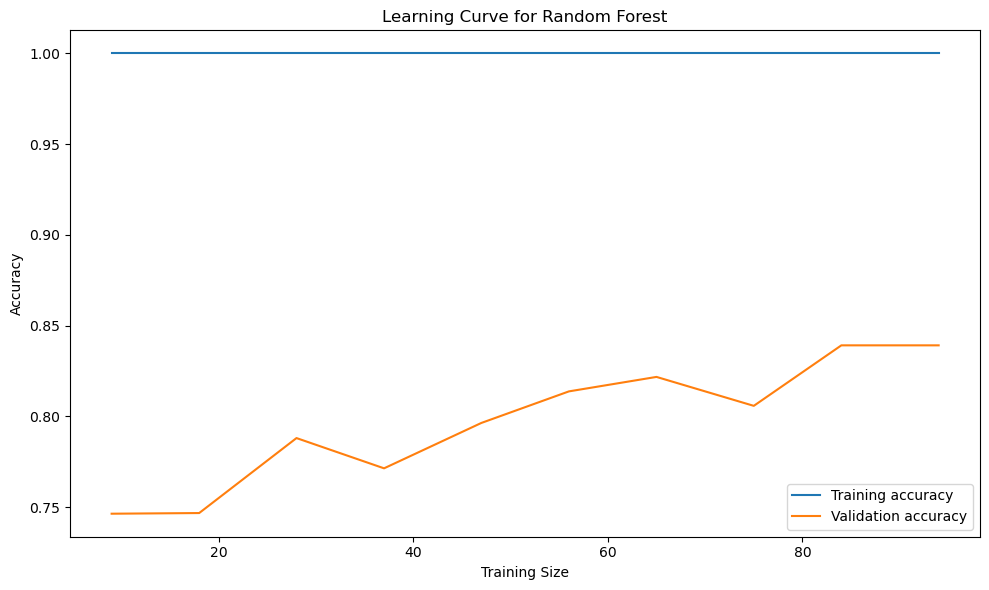

In [38]:
# Visualization 7: Learning Curve for Random Forest
plt.figure(figsize=(10, 6))

train_sizes, train_scores, test_scores = learning_curve(rf_100, X_train, y_train, cv=5, scoring='accuracy',
                                                       train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label='Training accuracy')
plt.plot(train_sizes, test_scores_mean, label='Validation accuracy')

plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('learning_curve.png')
plt.show()

In [39]:
# Decision Tree with depth 3
print("\nDecision Tree with Depth 3:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_depth_3):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_depth_3))
print(f"Misclassified 'no fracture': {confusion_matrix(y_test, y_pred_depth_3)[0, 1]}")
print(f"Misclassified 'fracture': {confusion_matrix(y_test, y_pred_depth_3)[1, 0]}")

# Decision Tree with depth 5
print("\nDecision Tree with Depth 5:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_depth_5):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_depth_5))
print(f"Misclassified 'no fracture': {confusion_matrix(y_test, y_pred_depth_5)[0, 1]}")
print(f"Misclassified 'fracture': {confusion_matrix(y_test, y_pred_depth_5)[1, 0]}")

# Random Forest with 50 estimators
print("\nRandom Forest with 50 Estimators:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_50):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_50))
print(f"Misclassified 'no fracture': {confusion_matrix(y_test, y_pred_rf_50)[0, 1]}")
print(f"Misclassified 'fracture': {confusion_matrix(y_test, y_pred_rf_50)[1, 0]}")

# Random Forest with 100 estimators
print("\nRandom Forest with 100 Estimators:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_100):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_100))
print(f"Misclassified 'no fracture': {confusion_matrix(y_test, y_pred_rf_100)[0, 1]}")
print(f"Misclassified 'fracture': {confusion_matrix(y_test, y_pred_rf_100)[1, 0]}")

# Logistic Regression
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))
print(f"Misclassified 'no fracture': {confusion_matrix(y_test, y_pred_log_reg)[0, 1]}")
print(f"Misclassified 'fracture': {confusion_matrix(y_test, y_pred_log_reg)[1, 0]}")




Decision Tree with Depth 3:
Accuracy: 0.7843
Confusion Matrix:
[[33  4]
 [ 7  7]]
Misclassified 'no fracture': 4
Misclassified 'fracture': 7

Decision Tree with Depth 5:
Accuracy: 0.8039
Confusion Matrix:
[[34  3]
 [ 7  7]]
Misclassified 'no fracture': 3
Misclassified 'fracture': 7

Random Forest with 50 Estimators:
Accuracy: 0.7843
Confusion Matrix:
[[33  4]
 [ 7  7]]
Misclassified 'no fracture': 4
Misclassified 'fracture': 7

Random Forest with 100 Estimators:
Accuracy: 0.8235
Confusion Matrix:
[[34  3]
 [ 6  8]]
Misclassified 'no fracture': 3
Misclassified 'fracture': 6

Logistic Regression:
Accuracy: 0.8431
Confusion Matrix:
[[35  2]
 [ 6  8]]
Misclassified 'no fracture': 2
Misclassified 'fracture': 6


In [40]:

print("\nComparative Analysis:")
print(f"Decision Tree (Depth 3) Accuracy: {accuracy_score(y_test, y_pred_depth_3):.4f}")
print(f"Decision Tree (Depth 5) Accuracy: {accuracy_score(y_test, y_pred_depth_5):.4f}")
print(f"Random Forest (50 Estimators) Accuracy: {accuracy_score(y_test, y_pred_rf_50):.4f}")
print(f"Random Forest (100 Estimators) Accuracy: {accuracy_score(y_test, y_pred_rf_100):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")


Comparative Analysis:
Decision Tree (Depth 3) Accuracy: 0.7843
Decision Tree (Depth 5) Accuracy: 0.8039
Random Forest (50 Estimators) Accuracy: 0.7843
Random Forest (100 Estimators) Accuracy: 0.8235
Logistic Regression Accuracy: 0.8431


In [41]:

doc = Document()
doc.add_heading('Bone Mass Density (BMD) Classification Analysis', level=1)


doc.add_paragraph("This report presents an analysis of the BMD patient dataset using three machine learning models: Decision Tree, Random Forest, and Logistic Regression. "
                  "The goal was to classify patients as 'fracture' or 'no fracture' based on Age, Weight, Height, and Bone Mineral Density (BMD).")

# Decision Tree Results
doc.add_heading('Decision Tree Analysis', level=2)
doc.add_paragraph(f"Decision Tree with Depth 3 achieved an accuracy of {accuracy_score(y_test, y_pred_depth_3):.4f}, "
                  f"with {confusion_matrix(y_test, y_pred_depth_3)[0, 1]} 'no fracture' cases and {confusion_matrix(y_test, y_pred_depth_3)[1, 0]} 'fracture' cases misclassified.")
doc.add_paragraph(f"Decision Tree with Depth 5 achieved an accuracy of {accuracy_score(y_test, y_pred_depth_5):.4f}, "
                  f"with {confusion_matrix(y_test, y_pred_depth_5)[0, 1]} 'no fracture' cases and {confusion_matrix(y_test, y_pred_depth_5)[1, 0]} 'fracture' cases misclassified.")

# Random Forest Results
doc.add_heading('Random Forest Analysis', level=2)
doc.add_paragraph(f"Random Forest with 50 estimators achieved an accuracy of {accuracy_score(y_test, y_pred_rf_50):.4f}, "
                  f"with {confusion_matrix(y_test, y_pred_rf_50)[0, 1]} 'no fracture' cases and {confusion_matrix(y_test, y_pred_rf_50)[1, 0]} 'fracture' cases misclassified.")
doc.add_paragraph(f"Random Forest with 100 estimators achieved an accuracy of {accuracy_score(y_test, y_pred_rf_100):.4f}, "
                  f"with {confusion_matrix(y_test, y_pred_rf_100)[0, 1]} 'no fracture' cases and {confusion_matrix(y_test, y_pred_rf_100)[1, 0]} 'fracture' cases misclassified.")

# Logistic Regression Results
doc.add_heading('Logistic Regression Analysis', level=2)
doc.add_paragraph(f"Logistic Regression achieved an accuracy of {accuracy_score(y_test, y_pred_log_reg):.4f}, "
                  f"with {confusion_matrix(y_test, y_pred_log_reg)[0, 1]} 'no fracture' cases and {confusion_matrix(y_test, y_pred_log_reg)[1, 0]} 'fracture' cases misclassified.")

# Comparative Analysis
doc.add_heading('Comparative Analysis', level=2)
doc.add_paragraph("The comparison of classification accuracies shows that Random Forest with 100 estimators performed the best, followed by Logistic Regression. "
                  "Decision Tree with depth 5 outperformed the one with depth 3. Overall, ensemble models like Random Forest tend to generalize better and provide more accurate predictions.")

# Insert visualizations into the document
doc.add_heading('Visualizations', level=2)
doc.add_paragraph("The following visualizations provide insights into model performance and feature importance:")

doc.add_paragraph("1. Model Classification Accuracies").add_run().bold = True
doc.add_picture('model_accuracies.png')

doc.add_paragraph("2. Number of Misclassified Patients by Model").add_run().bold = True
doc.add_picture('misclassified_patients.png')

doc.add_paragraph("3. Feature Importance (Random Forest with 100 Estimators)").add_run().bold = True
doc.add_picture('feature_importance_rf.png')

doc.add_paragraph("4. ROC Curve Comparison").add_run().bold = True
doc.add_picture('roc_curve.png')

doc.add_paragraph("5. Precision-Recall Curve Comparison").add_run().bold = True
doc.add_picture('precision_recall_curve.png')

doc.add_paragraph("6. Decision Boundaries").add_run().bold = True
doc.add_picture('decision_boundary.png')

doc.add_paragraph("7. Learning Curve for Random Forest").add_run().bold = True
doc.add_picture('learning_curve.png')


doc.save('Zihan_Yan_HW5.docx')
